# Семинар 3. Фреймворки, критик, голосование и план: сколько стоит каждый

Третья неделя дала три лекции: фреймворки, Reflection и Self-Consistency, Planning. Сегодня собираем всё это руками на одном агенте и ведём **одну таблицу денег** через весь семинар. Каждая строка таблицы: сколько вызовов, сколько токенов, сколько центов и сколько верных ответов.

Главный прибор семинара это счётчик на уровне HTTP. Голый цикл, LangGraph и smolagents ходят в OpenRouter через один и тот же клиент, и мы видим каждый запрос: сколько сообщений, сколько инструментов, какой системный промпт подложила библиотека и во что это обошлось. Цену каждого вызова OpenRouter возвращает сам в поле `usage.cost`.

Тезис курса прежний: **хороший агент на дешёвой модели обходится дешевле сильной модели в одиночку при том же качестве.** Сегодняшний вопрос к нему: сколько из этой экономии съедает фреймворк и какой паттерн недели окупается.

Девять спринтов, десять дырок, ни одна не длиннее десяти строк. Пояснения к дыркам, хронометраж и домашка в `README.md`.

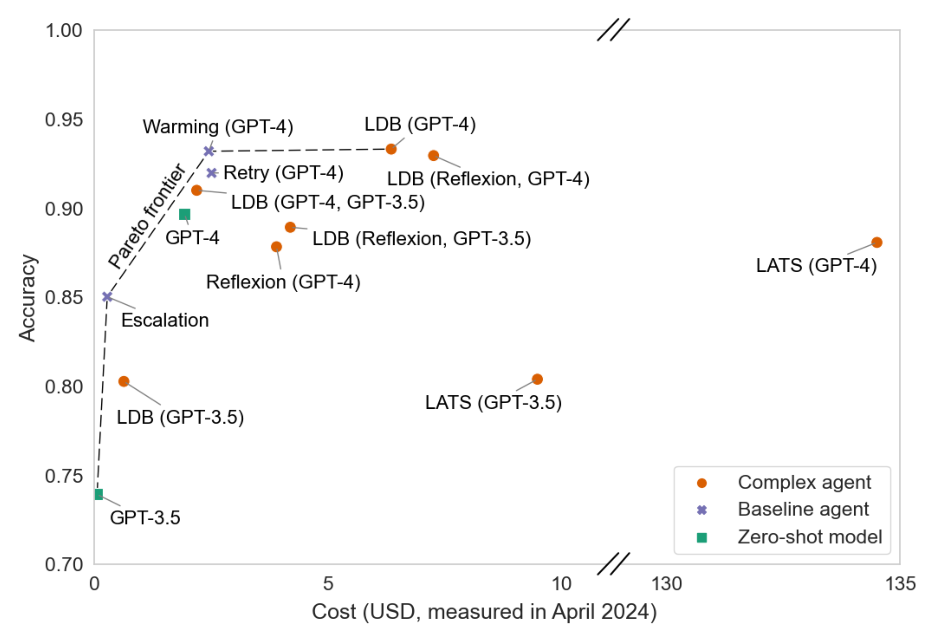

*Kapoor et al., 2024. AI Agents That Matter: точность против цены. Сложные агенты часто лежат правее простых базовых линий и не выше их. Сегодня строим такую картинку для своего агента*

## Что нужно

**Ключ** OpenRouter: локально файл `.env` рядом с ноутбуком, в Kaggle секрет `OPENROUTER_API_KEY`. **Данные**: папка `data` рядом с ноутбуком, в ней стартовый набор свежих вопросов из первой домашки; в Kaggle датасет `seminar03-data`. **Интернет**: агент ищет в Википедии, основная часть ответов лежит в снимке в `data`, остальное идёт в живую Википедию, в Kaggle включите Internet. Docker сегодня не нужен.

**Бюджет.** Полный прогон на сорока вопросах стоит порядка доллара, почти всё съедают строки с Sonnet. Если бюджет тесный, уменьшите `STRONG_SAMPLE`.

In [103]:
%pip install -q requests pydantic python-dotenv pandas matplotlib numpy httpx langgraph langchain langchain-openai smolagents

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os, re, sys, json, time, hashlib, threading
from pathlib import Path
from dataclasses import dataclass, field
from concurrent.futures import ThreadPoolExecutor
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field
import httpx
import gzip

from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.agents.middleware import wrap_model_call
from langchain_core.messages import HumanMessage
from langchain.agents.middleware import HumanInTheLoopMiddleware, ModelCallLimitMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

from smolagents import ToolCallingAgent, CodeAgent, OpenAIServerModel, tool as smol_tool

from ddgs import DDGS

c:\anaconda3\envs\agents\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass
try:
    from kaggle_secrets import UserSecretsClient
    os.environ.setdefault("OPENROUTER_API_KEY", UserSecretsClient().get_secret("OPENROUTER_API_KEY"))
except Exception:
    pass
KEY = os.getenv("OPENROUTER_API_KEY")
assert KEY, "нет ключа: положите его в .env рядом с ноутбуком или в Kaggle Secrets"

In [3]:
USE_PROXY = True
# OpenRouter не пускает из РФ
# Поэтому поднял небольшой прокси

In [4]:
if USE_PROXY:
    PROXY_URL = os.getenv("PROXY_URL")
    CHAT_URL = PROXY_URL + "chat/completions"
    BASE_URL = PROXY_URL
else:
    CHAT_URL = "https://openrouter.ai/api/v1/chat/completions"
    BASE_URL = "https://openrouter.ai/api/v1"

In [5]:
CHEAP, MID, STRONG = "openai/gpt-4o-mini", "anthropic/claude-haiku-4.5", "anthropic/claude-sonnet-4.6"
COLORS = {"violet": "#5436A3", "amber": "#F09000", "teal": "#00838F", "red": "#C43C3C", "grey": "#787882"}
DATA = next((p for p in [Path("data"), Path("/kaggle/input/seminar03-data"), Path("/kaggle/input/seminar03-data/data")]
             if (p / "fresh_2026.jsonl").exists()), Path("data"))
SAMPLE, STRONG_SAMPLE = 40, 40
Path("img").mkdir(exist_ok=True)

def load_jsonl(name):
    return [json.loads(line) for line in (DATA / name).read_text(encoding="utf-8").splitlines() if line.strip()]

def pmap(fn, items, workers=6):
    with ThreadPoolExecutor(workers) as ex:
        return list(ex.map(fn, items))

## Спринт 1. Счётчик: что на самом деле уходит в сеть

Все три исполнения агента, голый цикл, LangGraph и smolagents, внутри пользуются OpenAI-совместимым клиентом, а тот ходит в сеть через библиотеку `httpx`. Если дать им всем один и тот же `httpx.Client` с крючком на ответ, мы увидим каждый вызов модели, чей бы код его ни сделал. Никакой магии и никаких сторонних сервисов наблюдаемости: только то, что ушло в сеть и что пришло обратно.

Крючок получает ответ, у ответа есть исходный запрос. Из запроса берём модель, число сообщений и инструментов, из ответа поле `usage`: токены на входе, на выходе и цену. Каждый вызов помечаем текущей меткой `TAG`, чтобы потом сложить деньги по конфигурациям. Первый запрос под каждой меткой сохраняем целиком: по нему видно, какой системный промпт подложила библиотека.

Дырка: `on_response`. Чекпоинт: один вызов модели оставляет в `CALLS` строку с токенами и ценой.

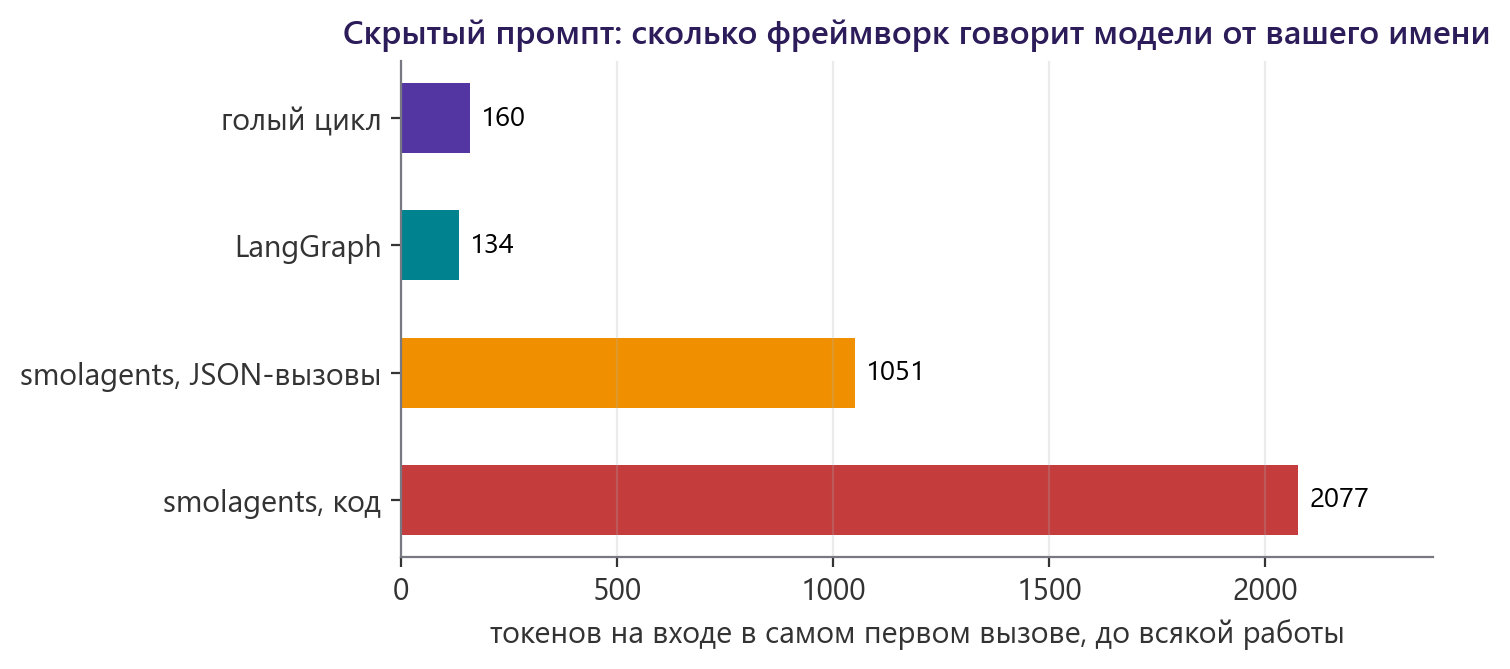

*Из седьмой лекции: сколько токенов уходит в первом же запросе у четырёх исполнений одного агента. Сегодня меряем то же самое своим счётчиком*

In [6]:
CALLS, FIRST, TAG = [], {}, {"now": "без метки"}

In [7]:
def on_response(response):
    response.read()
    request = json.loads(response.request.content or b"{}")
    usage = response.json().get("usage") or {}
    FIRST.setdefault(TAG["now"], request)
    CALLS.append({
        "tag":TAG["now"],
        "model": request.get("model", "?").split("/")[-1],
        "messages": len(request.get("messages", [])),
        "tools": len(request.get("tools", [])),
        "prompt": usage.get("prompt_tokens", 0),
        "completion": usage.get("completion_tokens", 0),
        "cost": usage.get("cost") or 0

    })



In [8]:
HTTP = httpx.Client(event_hooks={"response": [on_response]}, timeout=180)
HEADERS = {"Authorization": f"Bearer {KEY}", "X-Title": "agents-course-seminar03"}

def chat(messages, model=CHEAP, tools=None, temperature=0.0):
    body = {"model": model, "messages": messages, "temperature": temperature}
    if tools:
        body["tools"] = tools
    for attempt in range(5):
        r = HTTP.post(f"{BASE_URL}/chat/completions", json=body, headers=HEADERS)
        if r.status_code == 200:
            return r.json()["choices"][0]["message"]
        time.sleep(2 * (attempt + 1))
    raise RuntimeError(f"HTTP {r.status_code}: {r.text[:200]}")

TAG["now"] = "проверка счётчика"
chat([{"role": "user", "content": "Say OK"}])
pd.DataFrame(CALLS)

,tag,model,messages,tools,prompt,completion,cost
0,проверка счётчика,gpt-4o-mini,1,0,9,2,0.000003


## Спринт 2. Инструменты и базовая линия

Агент тот же, что в первой домашке: свежие вопросы о событиях 2026 года и живая Википедия. Инструментов два, оба даны готовыми. `web_search` ищет статью и возвращает её вступление и ещё два заголовка. `page_find` заглядывает в полный текст статьи и возвращает строки с ключевыми словами: факты о 2026 годе лежат в теле обзорных страниц вроде «2026 in Japan», а не во вступлениях.

Ответы Википедии складываются в словарь `WIKI_CACHE`, и он стартует со снимка `data/wiki_snapshot.json.gz`: это все запросы, которые агенты сделали на эталонном прогоне этого ноутбука 25.09.2026. Чего нет в снимке, идёт в живую Википедию. Так девять конфигураций сравниваются на одних и тех же страницах, прогон идёт быстрее, а группа в одной сети не упирается в лимиты Википедии. Если Википедия недоступна, инструмент падает с ошибкой, а не отвечает молча «ничего не найдено»: иначе сбой сети записался бы в ошибки модели. И ещё одно требование Википедии: в заголовке `User-Agent` должна быть контактная ссылка, без неё API отвечает 403.

Вопросы первые сорок из стартового набора. Эталонный агент первой домашки ответил на 25 из них, это поле `agent_ok`: будет с чем сравнить.

Базовая линия это голый цикл с первого семинара, сжатый до двадцати строк, с детектором повторов и лимитом шагов. На последнем шаге цикл не передаёт модели инструменты и просит ответить тем, что она успела найти. `run_config` прогоняет конфигурацию по вопросам параллельно под своей меткой, `report` складывает деньги из `CALLS`, `wrong` показывает ответы, которые проверка сочла неверными.

Проверка ответа: все слова эталона после нормализации есть в ответе, порядок не важен. На подготовке первая версия искала эталон подстрокой, и ответ «March 15, 2026» при эталоне «15 March» уходил в ошибки. Это тот самый урок одиннадцатой лекции: прежде чем верить проценту, прочитайте глазами, что проверка записала в неверные.

Чекпоинт: строка «голый цикл, mini» в таблице и список неверных ответов.

In [9]:



tasks = load_jsonl("fresh_2026.jsonl")[-SAMPLE:]
WIKI = "https://en.wikipedia.org/w/api.php"
WIKI_HEADERS = {"User-Agent": "agents-course-seminar03/1.0 (https://t.me/artemovma)"}
SNAPSHOT = DATA / "wiki_snapshot.json.gz"
WIKI_CACHE = json.loads(gzip.decompress(SNAPSHOT.read_bytes())) if SNAPSHOT.exists() else {}

def wiki(params):
    key = json.dumps(params, sort_keys=True)
    for attempt in range(4):
        if key not in WIKI_CACHE:
            try:
                r = httpx.get(WIKI, params={**params, "format": "json"}, headers=WIKI_HEADERS, timeout=25)
                r.raise_for_status()
                WIKI_CACHE[key] = r.json().get("query", {})
            except httpx.HTTPError as e:
                error = e
                time.sleep(2 * (attempt + 1))
                continue
        return WIKI_CACHE[key]
    raise RuntimeError(f"Википедия не отвечает: {error}")

def web_search(query: str) -> str:
    """Search English Wikipedia: returns the intro of the best article and the titles of two more articles."""
    hits = wiki({"action": "query", "list": "search", "srsearch": query, "srlimit": 3}).get("search", [])
    if not hits:
        return "nothing found"
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "exintro": 1, "titles": hits[0]["title"]}).get("pages", {})
    intro = " ".join(next(iter(pages.values()), {}).get("extract", "").split())[:1200]
    return f"[{hits[0]['title']}] {intro} | other articles: " + ", ".join(h["title"] for h in hits[1:])

def page_find(title: str, keywords: str) -> str:
    """Look inside the full text of a Wikipedia article and return the lines that contain the keywords."""
    pages = wiki({"action": "query", "prop": "extracts", "explaintext": 1, "titles": title, "redirects": 1}).get("pages", {})
    text = next(iter(pages.values()), {}).get("extract", "")
    if not text:
        return "no such page"
    kws = [w for w in re.findall(r"\w+", keywords.lower()) if len(w) > 2]
    lines = [l.strip() for l in text.splitlines() if l.strip() and sum(w in l.lower() for w in kws) >= max(1, (len(kws) + 1) // 2)]
    return "\n".join(l[:350] for l in lines[:5]) or "keywords not found on the page"

len(tasks), sum(t["agent_ok"] for t in tasks), len(WIKI_CACHE), web_search("2026 Winter Paralympics")[:200], page_find("2026 in Ukraine", "Paralympics boycott")

(40,
 29,
 0,
 '[2026 Winter Paralympics] The 2026 Winter Paralympics (Italian: Giochi paralimpici invernali di Milano Cortina 2026), also known as the Milano Cortina 2026 Winter Paralympic Games, were the 14th editi',
 'Ukraine boycotts the opening ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.\n15 March – Ukraine boycotts the closing ceremony of the 2026 Winter Paralympics in Italy in protest over Russian athletes being allowed to compete under the Russian flag after the lifting of sanctions imposed over the Russian invasion in 2022.')

In [10]:
DDG_CACHE = {}                        
DDG_SLOTS = threading.Semaphore(2)

def ddg_search(query: str) -> str:
    """Search the web via DuckDuckGo (not only Wikipedia). Use it when a fact is missing from Wikipedia or fresher information is needed. Returns a few result snippets, not full pages."""
    if query in DDG_CACHE:                           # повтор запроса: отвечаем из кэша, ровно как для Википедии
        return DDG_CACHE[query]
    error = None
    for attempt in range(3):
        try:
            with DDG_SLOTS, DDGS() as ddgs:          
                hits = list(ddgs.text(query, max_results=3))
            break                                    
        except Exception as e:
            error = e
            time.sleep(2 * (attempt + 1))            # линейная пауза между повторами
    else:                                            
        raise RuntimeError(f"DuckDuckGo не отвечает: {error}") 

    parts = [f"[{h.get('title', '').strip()}] {' '.join(h.get('body', '').split())[:800]}" for h in hits]
    DDG_CACHE[query] = "\n".join(parts) or "nothing found"
    return DDG_CACHE[query]

In [11]:
AGENT_SYSTEM = ("You answer questions about events of 2026 using Wikipedia tools. Never answer from memory, do not repeat the same call. "
                "When done, reply with the short answer only, no explanation.")
BARE_TOOLS = [
    {"type": "function", "function": {"name": "web_search", "description": web_search.__doc__,
     "parameters": {"type": "object", "properties": {"query": {"type": "string", "description": "short query: a name, a title, an event"}}, "required": ["query"]}}},
    {"type": "function", "function": {"name": "page_find", "description": page_find.__doc__,
     "parameters": {"type": "object", "properties": {"title": {"type": "string", "description": "exact article title, e.g. 2026 in Japan"},
                                                     "keywords": {"type": "string", "description": "two to five keywords"}},
                    "required": ["title", "keywords"]}}}]
FUNCS = {"web_search": web_search, "page_find": page_find}
LAST_STEP = "No more tool calls. Answer now with what you found."

def bare_agent(question, model=CHEAP, max_steps=6):
    messages, seen = [{"role": "system", "content": AGENT_SYSTEM}, {"role": "user", "content": question}], set()
    for step in range(max_steps):
        last = step == max_steps - 1
        if last:
            messages.append({"role": "user", "content": LAST_STEP})
        msg = chat(messages, model, None if last else BARE_TOOLS)
        messages.append({k: v for k, v in msg.items() if k in ("role", "content", "tool_calls") and v})
        calls = msg.get("tool_calls") or []
        if not calls:
            return msg.get("content") or ""
        for c in calls:
            key = (c["function"]["name"], c["function"]["arguments"])
            result = "repeated call, answer now" if key in seen else FUNCS[key[0]](**json.loads(key[1]))
            seen.add(key)
            messages.append({"role": "tool", "tool_call_id": c["id"], "content": result})
    return messages[-1].get("content") or ""

In [12]:

BARE_TOOLS.append({"type": "function", "function": {
    "name": "ddg_search",
    "description": " ".join(ddg_search.__doc__.split()),
    "parameters": {"type": "object",
                   "properties": {"query": {"type": "string", "description": "web search query (not only Wikipedia)"}},
                   "required": ["query"]}}})
FUNCS["ddg_search"] = ddg_search

In [13]:
NUMBERS = {w: str(n) for n, w in enumerate("zero one two three four five six seven eight nine ten eleven twelve".split())}

def norm(text):
    return " ".join(NUMBERS.get(w, w) for w in re.sub(r"\b(a|an|the)\b|[^\w\s]", " ", str(text).lower()).split())

def is_correct(task, answer):
    return set(norm(task["answer"]).split()) <= set(norm(answer).split())

RESULTS = {}

def run_config(tag, fn, sample=None, workers=6):
    sample = sample or tasks
    TAG["now"] = tag
    def one(task):
        try:
            return fn(task["question"])
        except Exception as e:
            return f"ошибка: {type(e).__name__}"
    answers = pmap(one, sample, workers)
    RESULTS[tag] = [{"id": t["id"], "answer": a, "ok": is_correct(t, a)} for t, a in zip(sample, answers)]
    return report([tag])

def report(tags=None):
    rows = []
    for tag in tags or RESULTS:
        res, calls = RESULTS[tag], [c for c in CALLS if c["tag"] == tag]
        n, ok, cost = len(res), sum(r["ok"] for r in res), sum(c["cost"] for c in calls)
        rows.append({"конфигурация": tag, "верно": f"{ok}/{n}", "доля": round(ok / n, 3), "вызовов на вопрос": round(len(calls) / n, 1),
                     "токенов на вопрос": round(sum(c["prompt"] + c["completion"] for c in calls) / n),
                     "центов на вопрос": round(cost / n * 100, 4), "центов за верный": round(cost / ok * 100, 4) if ok else None})
    return pd.DataFrame(rows)

def wrong(tag, n=10):
    return pd.DataFrame([{"эталон": t["answer"], "ответ": str(r["answer"])[:110]}
                         for t, r in zip(tasks, RESULTS[tag]) if not r["ok"]][:n])

TAG["now"] = "проба"
print(bare_agent(tasks[0]["question"]), "| эталон:", tasks[0]["answer"])
run_config("голый цикл, mini", bare_agent)

The People Mover at São Paulo/Guarulhos International Airport opens on February 20, 2026. | эталон: GRU Airport People Mover


,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",21/40,0.525,2.9,1608,0.0266,0.0507


In [14]:
wrong("голый цикл, mini")

,эталон,ответ
0,GRU Airport People Mover,The People Mover at São Paulo/Guarulhos Intern...
1,Michaelmas Island,A man was killed in a shark attack off the coa...
2,conspiracy to commit arson,Counter Terrorism Policing investigated a wave...
3,Clay Fuller,ошибка: RuntimeError
4,prime minister,Keir Starmer resigned as the leader of the Lab...
5,850,ошибка: RuntimeError
6,Urgent Care Centre,"An urgent care facility opened in St. John's, ..."
7,66,At least 81 people were killed in the Kenya fl...
8,Line S2,ошибка: RuntimeError
9,Antonello da Messina,"Paintings by Cézanne, Renoir, and Matisse were..."


## Спринт 3. LangGraph

В LangChain 1.x функция `create_agent` собирает тот же ReAct-цикл в виде графа LangGraph: узел модели, узел инструментов, ребро «есть вызовы инструментов, иди выполнять». Инструменты описываются декоратором `tool`: имя, схема из подсказок типов, описание из докстринга. Наши функции уже снабжены докстрингами, поэтому обёртка в одну строку. Или так кажется: проверим счётчиком.

Модель подключаем через `ChatOpenAI` с адресом OpenRouter и **нашим** клиентом `http_client=HTTP`: так каждый вызов LangGraph попадает в счётчик.

Дырка: `run_langgraph`. Собрать агента с моделью, инструментами, системным промптом и промежуточными слоями из списка `LG_MIDDLEWARE` (пока он пустой), вызвать на вопросе с лимитом рекурсии и вернуть весь список сообщений: в нём и ответ, и то, что вернули инструменты, это понадобится критику. `ask_langgraph` рядом берёт из списка только текст ответа. Параметры `temperature` и `extra` понадобятся во второй половине семинара: для голосования и для плана в системном промпте.

Чекпоинт: строка «LangGraph как есть, mini» и список её неверных ответов.

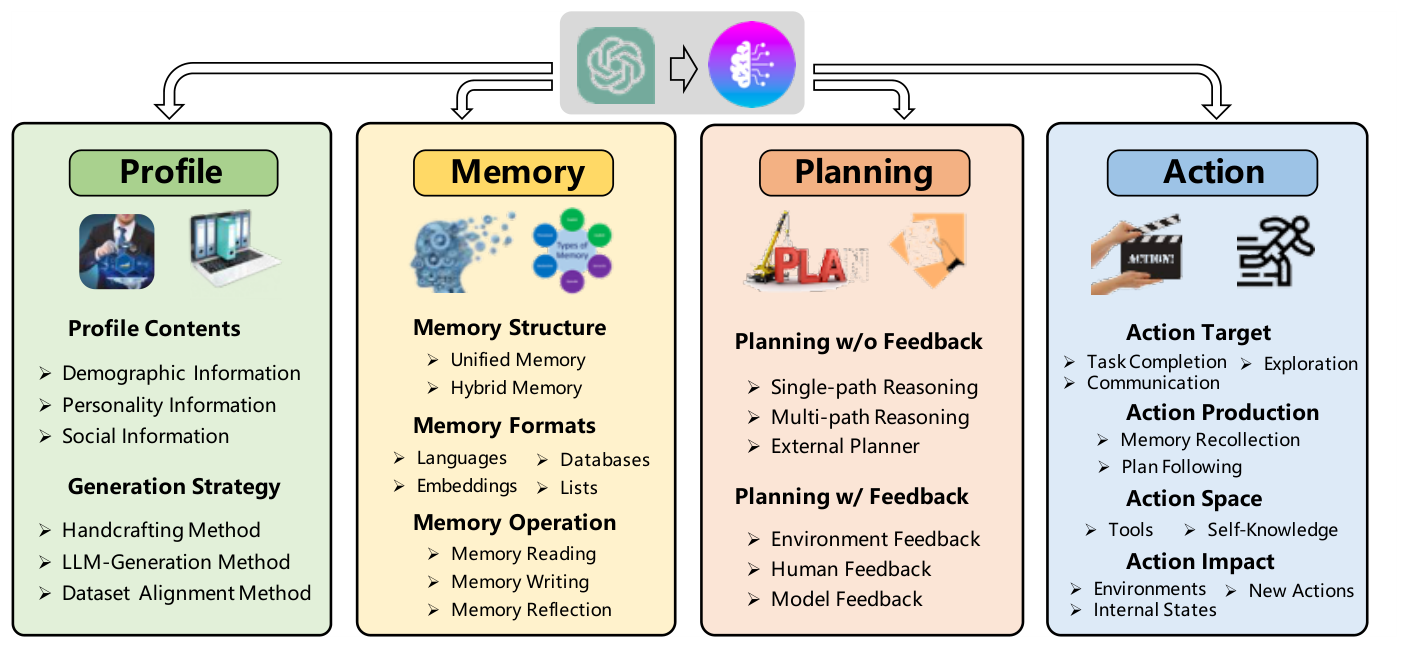

*Wang et al., 2023. Устройство агента в четырёх модулях. Фреймворк не добавляет пятого модуля, он даёт готовую проводку между этими четырьмя*

In [15]:


LC_TOOLS = [tool(web_search), tool(page_find), tool(ddg_search)]
LG_MIDDLEWARE = []

def lc_model(model=CHEAP, temperature=0.0):
    return ChatOpenAI(model=model, base_url=BASE_URL, api_key=KEY, http_client=HTTP, temperature=temperature) #!

In [16]:
def run_langgraph(question, model=CHEAP, temperature=0.0, extra=""):
    agent = create_agent(lc_model(model, temperature), tools=LC_TOOLS, system_prompt=AGENT_SYSTEM + extra, middleware=LG_MIDDLEWARE)
    out = agent.invoke(
        {"messages": [{"role": "user", "content": question}]},
        {"recursion_limit": 14}
    )
    return out["messages"]


In [17]:
def ask_langgraph(question, model=CHEAP, temperature=0.0, extra=""):
    return run_langgraph(question, model, temperature, extra)[-1].content

TAG["now"] = "проба"
print(ask_langgraph(tasks[0]["question"]), "| эталон:", tasks[0]["answer"])
run_config("LangGraph как есть, mini", ask_langgraph)
wrong("LangGraph как есть, mini", 15)

The People Mover at São Paulo/Guarulhos International Airport opens on February 20, 2026. | эталон: GRU Airport People Mover


,эталон,ответ
0,GRU Airport People Mover,The People Mover at São Paulo/Guarulhos Intern...
1,Michaelmas Island,A man was killed in a shark attack off the coa...
2,conspiracy to commit arson,Counter Terrorism Policing investigated a wave...
3,prime minister,Keir Starmer resigned as the leader of the Lab...
4,Line S2,Line 6 of the Nanjing Metro is expected to ope...
5,Antonello da Messina,"Paintings by Cézanne, Renoir, and Matisse were..."
6,Baku and Tbilisi,Cities that resumed passenger services in May ...
7,Operation Southern Spear,The operation involved the United States targe...
8,Indiana Hoosiers,ошибка: RuntimeError
9,Cyclone Gezani,The name of the intense tropical cyclone that ...


In [18]:
for tag in ["голый цикл, mini", "LangGraph как есть, mini"]:
    print(tag, json.dumps(FIRST[tag]["tools"][1]["function"]["parameters"]["properties"], ensure_ascii=False))

голый цикл, mini {"title": {"type": "string", "description": "exact article title, e.g. 2026 in Japan"}, "keywords": {"type": "string", "description": "two to five keywords"}}
LangGraph как есть, mini {"title": {"type": "string"}, "keywords": {"type": "string"}}


### Чего фреймворк не сделал за нас

Та же модель, тот же промпт, те же функции. Доля верных может совпасть с голым циклом в пределах шума, но посмотрите, из чего состоят ошибки и сколько стоил вопрос. Счётчик показывает две разницы.

Первая в списке неверных ответов: большая часть это не ошибки модели, а `GraphRecursionError`. Агент не уложился в лимит переходов, и граф упал, выбросив всё найденное. Наш голый цикл в той же ситуации делал последний шаг без инструментов и с просьбой `LAST_STEP` ответить тем, что уже найдено. LangGraph так не делает: он честно исполняет граф, а что делать на последнем шаге, решаете вы.

Вторая в ячейке выше: что на самом деле ушло в сеть. `tool(page_find)` построил схему из подсказок типов, а описаний аргументов там нет. Подсказка «exact article title, e.g. 2026 in Japan», которая вела модель к обзорным страницам, молча пропала. Промпт поменялся, и никто этого не просил.

Обе починки занимают по несколько строк. Описания аргументов передаём схемой Pydantic через `args_schema`, строки те же, что у голого цикла. Последний шаг чиним промежуточным слоем (middleware): в LangChain 1.x это функция, которая оборачивает каждый вызов модели и может поменять запрос. Запрос приходит объектом `ModelRequest`, в нём история `request.messages` и список инструментов `request.tools`; `request.override(tools=[])` возвращает копию запроса без инструментов, `handler(request)` вызывает модель дальше по цепочке.

Дырка: `last_step_without_tools`. Если в истории уже пять ответов модели, шестой вызов делать без инструментов и с сообщением `LAST_STEP` в конце истории. Просьба не для красоты: Claude после результатов инструментов без инструментов в запросе иногда просто завершает ход с пустым ответом, на подготовке так Sonnet потерял пять вопросов из сорока. Слой добавляем в `LG_MIDDLEWARE`, и с этого момента им пользуются все прогоны LangGraph до конца семинара.

Чекпоинт: строка «LangGraph, mini» рядом с «как есть» и голым циклом.

In [19]:


class SearchArgs(BaseModel):
    query: str = Field(description="short query: a name, a title, an event")

class FindArgs(BaseModel):
    title: str = Field(description="exact article title, e.g. 2026 in Japan")
    keywords: str = Field(description="two to five keywords")

class DDGArgs(BaseModel):
    query: str = Field(description="web search query (not only Wikipedia)")

# Пересобираем список целиком, а не append: ячейку безопасно перезапускать
LC_TOOLS = [tool(web_search, args_schema=SearchArgs),
            tool(page_find, args_schema=FindArgs),
            tool(ddg_search, args_schema=DDGArgs)]

In [20]:
@wrap_model_call
def last_step_without_tools(request, handler):
    if sum(m.type == 'ai' for m in request.messages) >= 5:
        request = request.override(tools=[], messages=request.messages + [HumanMessage(LAST_STEP)])
    return handler(request)
    


In [21]:
LG_MIDDLEWARE.append(last_step_without_tools)
run_config("LangGraph, mini", ask_langgraph)
report(["голый цикл, mini", "LangGraph как есть, mini", "LangGraph, mini"])

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",21/40,0.525,2.9,1608,0.0266,0.0507
1,"LangGraph как есть, mini",21/40,0.525,3.0,1599,0.0266,0.0507
2,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445




Сравним их ошибки

In [22]:
def compare(a, b):
    A, B = RESULTS[a], RESULTS[b]
    pairs = list(zip(A, B))
    return {
        "оба верно": sum(x["ok"] and y["ok"] for x, y in pairs),
        f"только {a}": sum(x["ok"] and not y["ok"] for x, y in pairs),   # "расхождения" в одну сторону
        f"только {b}": sum(not x["ok"] and y["ok"] for x, y in pairs),   # и в другую
        "оба неверно": sum(not x["ok"] and not y["ok"] for x, y in pairs),
    }

compare("голый цикл, mini", "LangGraph, mini")

{'оба верно': 20,
 'только голый цикл, mini': 1,
 'только LangGraph, mini': 5,
 'оба неверно': 14}

Разница выглядит как шум. (Надо было t=0 и для bare agent, он мог и 26 выдать)

Одна ошибка в рамках погрешности на самом деле, но возьмём LangGraph

In [24]:
pd.Series([c["tag"] for c in CALLS]).value_counts()

LangGraph как есть, mini    120
LangGraph, mini             119
голый цикл, mini            117
проба                         6
проверка счётчика             1
Name: count, dtype: int64

## Спринт 4. smolagents: вызовы инструментов и код

У smolagents два агента. `ToolCallingAgent` зовёт инструменты через tool calling, как наш цикл. `CodeAgent` вместо вызова инструмента пишет кусок Python, в котором инструменты это обычные функции: может вызвать несколько подряд, отфильтровать, посчитать. Это идея CodeAct из седьмой лекции.

Инструмент в smolagents описывается декоратором `tool`, и библиотека строже LangChain: у каждого аргумента обязано быть описание в разделе `Args:` докстринга, иначе сразу `DocstringParsingException`. Описание аргумента это часть промпта, так что строгость полезная.

Две дырки. Первая: `smol_web_search`, обёртка поиска с правильным докстрингом, образец `smol_page_find` рядом. Вторая: `ask_smol`, агент нужного вида с моделью через наш `HTTP`, инструментами, системным текстом в `instructions` и лимитом шагов.

Чекпоинт: две строки smolagents и таблица «сколько весит пустой запрос»: один и тот же простой вопрос во всех четырёх исполнениях.

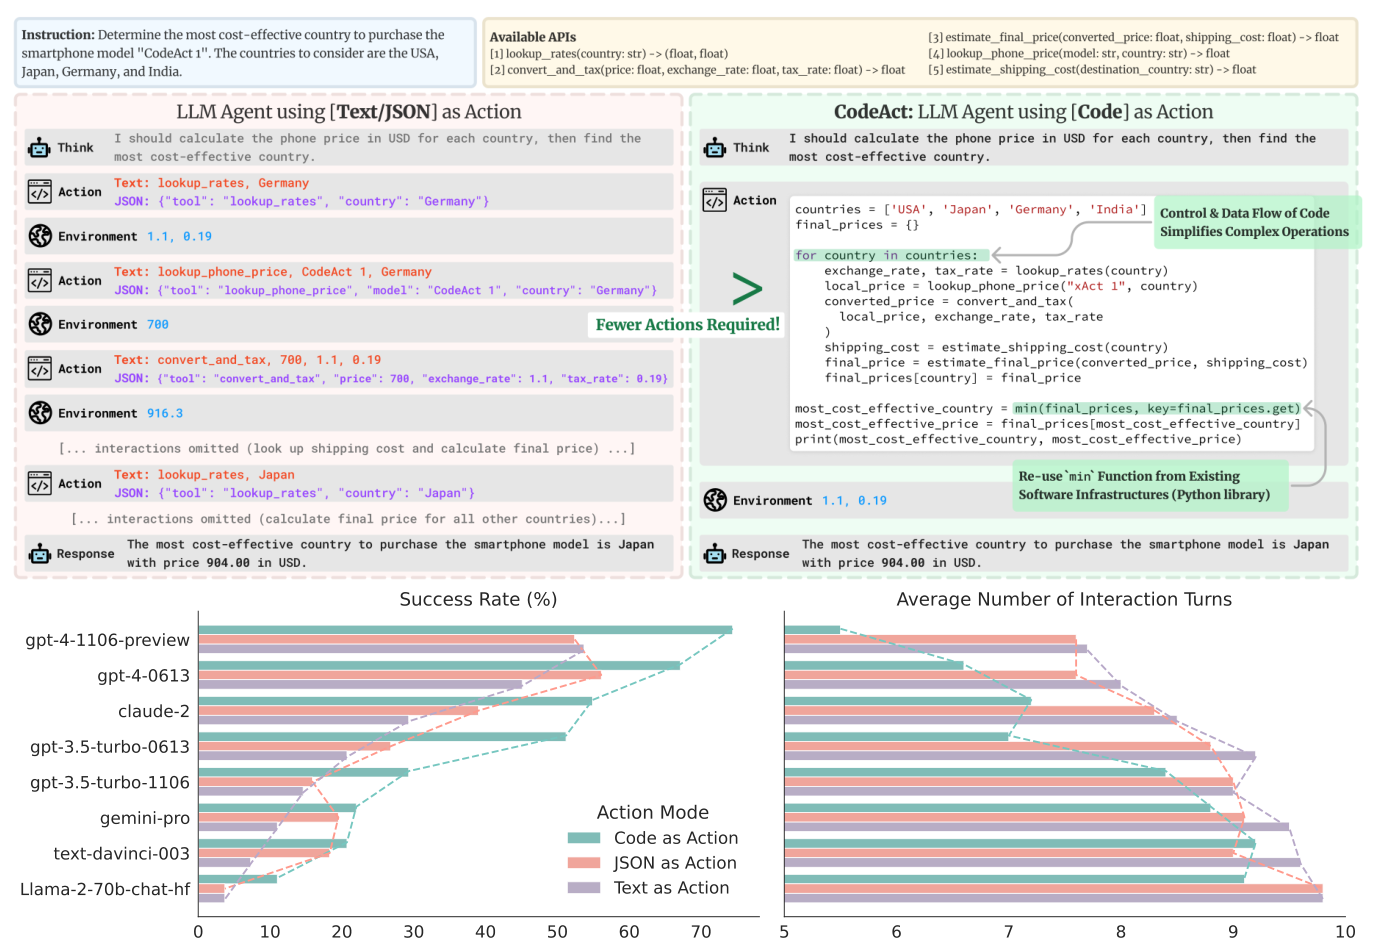

*Wang et al., 2024. CodeAct: действие в виде кода вместо JSON-вызова. Меньше шагов, зато длиннее системный промпт*

In [25]:


def smol_model(model=CHEAP):
    return OpenAIServerModel(model_id=model, api_base=BASE_URL, api_key=KEY, client_kwargs={"http_client": HTTP}, temperature=0)

@smol_tool
def smol_page_find(title: str, keywords: str) -> str:
    """Look inside the full text of a Wikipedia article and return the lines that contain the keywords.

    Args:
        title: exact article title, e.g. 2026 in Japan
        keywords: two to five keywords
    """
    return page_find(title, keywords)

c:\anaconda3\envs\agents\Lib\site-packages\smolagents\tools.py:1134: UserWarning: Function 'smol_page_find' has decorators other than @tool. This may cause issues with serialization in the remote executor. See issue #1626.
  warnings.warn(


In [27]:
@smol_tool
def smol_web_search(query: str) -> str:
    """Search English Wikipedia: returns the intro of best acticle

    Args:
            query: short query: a name, a date, an event
    """
    return web_search(query)


In [28]:
@smol_tool
def smol_ddg_search(query: str) -> str:
    """Search the web via DuckDuckGo (not only Wikipedia). Use it when a fact is missing from Wikipedia or fresher information is needed. Returns a few result snippets, not full pages.

    Args:
        query: web search query (not only Wikipedia)
    """
    return ddg_search(query)

SMOL_TOOLS = [smol_web_search, smol_page_find, smol_ddg_search]



c:\anaconda3\envs\agents\Lib\site-packages\smolagents\tools.py:1134: UserWarning: Function 'smol_ddg_search' has decorators other than @tool. This may cause issues with serialization in the remote executor. See issue #1626.
  warnings.warn(


In [ ]:
# Тут нужна подсказка только для smolagents, он пытается с final другой инструмент звать
# SMOL_EXTRA = "\nCall final_answer alone, in its own step: never together with other tool calls."

def ask_smol(question, kind="tools", model=CHEAP, max_steps=6):
    cls = ToolCallingAgent if kind == "tools" else CodeAgent
    agent = cls(tools=SMOL_TOOLS, model=smol_model(model),
                instructions=AGENT_SYSTEM, # + SMOL_EXTRA,
                max_steps=max_steps, verbosity_level=0)
    return str(agent.run(question))




In [30]:
PROBE = "What is 2 + 2? Reply with the number only."
for tag, fn in [("пустой вопрос: голый цикл", bare_agent), ("пустой вопрос: LangGraph", ask_langgraph),
                ("пустой вопрос: smolagents, инструменты", lambda q: ask_smol(q, "tools")),
                ("пустой вопрос: smolagents, код", lambda q: ask_smol(q, "code"))]:
    TAG["now"] = tag
    fn(PROBE)
empty = pd.DataFrame([c for c in CALLS if c["tag"].startswith("пустой")])
empty.groupby("tag", sort=False).agg(вызовов=("prompt", "size"), первый_запрос=("prompt", "first"), всего_токенов=("prompt", "sum"),
                                      центов=("cost", lambda s: round(s.sum() * 100, 4)))

,вызовов,первый_запрос,всего_токенов,центов
tag,,,,
пустой вопрос: голый цикл,1,238,238,0.0037
пустой вопрос: LangGraph,1,238,238,0.0037
"пустой вопрос: smolagents, инструменты",1,1269,1269,0.0199
"пустой вопрос: smolagents, код",1,2201,2201,0.0341


In [31]:
content = FIRST["пустой вопрос: smolagents, код"]["messages"][0]["content"]
system_text = content if isinstance(content, str) else " ".join(part.get("text", "") for part in content)
print(len(system_text), "символов системного промпта у CodeAgent. Начало:\n")
print(system_text[:1200])

9432 символов системного промпта у CodeAgent. Начало:

You are an expert assistant who can solve any task using code blobs. You will be given a task to solve as best you can.
To do so, you have been given access to a list of tools: these tools are basically Python functions which you can call with code.
To solve the task, you must plan forward to proceed in a series of steps, in a cycle of Thought, Code, and Observation sequences.

At each step, in the 'Thought:' sequence, you should first explain your reasoning towards solving the task and the tools that you want to use.
Then in the Code sequence you should write the code in simple Python. The code sequence must be opened with '<code>', and closed with '</code>'.
During each intermediate step, you can use 'print()' to save whatever important information you will then need.
These print outputs will then appear in the 'Observation:' field, which will be available as input for the next step.
In the end you have to return a final answer u

In [32]:
import difflib

def dump(tag):
    req = FIRST[tag]
    # Сравниваем только то, что должно совпасть: системное сообщение и схемы инструментов.
    # Вопрос пользователя в этих запросах разный, поэтому его выкидываем.
    part = {"system": req["messages"][0], "tools": req.get("tools")}
    return json.dumps(part, ensure_ascii=False, indent=1, sort_keys=True).splitlines()  # sort_keys: diff покажет смысл, а не порядок ключей

for line in difflib.unified_diff(dump("голый цикл, mini"), dump("LangGraph как есть, mini"),
                                 "голый цикл", "LangGraph как есть", lineterm="", n=1):
    print(line)



--- голый цикл
+++ LangGraph как есть
@@ -13,3 +13,2 @@
       "query": {
-       "description": "short query: a name, a title, an event",
        "type": "string"
@@ -32,3 +31,2 @@
       "keywords": {
-       "description": "two to five keywords",
        "type": "string"
@@ -36,3 +34,2 @@
       "title": {
-       "description": "exact article title, e.g. 2026 in Japan",
        "type": "string"
@@ -56,3 +53,2 @@
       "query": {
-       "description": "web search query (not only Wikipedia)",
        "type": "string"


In [33]:
# сколько вопросов LangGraph уронил вместо ответа
print(sum("GraphRecursionError" in str(r["answer"]) for r in RESULTS["LangGraph как есть, mini"]), "из", len(tasks))

0 из 40


In [34]:
run_config("smolagents инструменты, mini", lambda q: ask_smol(q, "tools"))
run_config("smolagents код, mini", lambda q: ask_smol(q, "code"))
report()

If you want to return an answer, please do not perform any other tool calls than the final answer tool call!

If you want to return an answer, please do not perform any other tool calls than the final answer tool call!

If you want to return an answer, please do not perform any other tool calls than the final answer tool call!

If you want to return an answer, please do not perform any other tool calls than the final answer tool call!

Reached max steps.

...

Code execution exceeded the maximum execution time of 30 seconds

Code execution exceeded the maximum execution time of 30 seconds

Code execution failed at line 'fatal_shark_attack_panama_city = smol_ddg_search("fatal shark attack Panama City 
June 2026")' due to: RuntimeError: DuckDuckGo не отвечает: No results found.

Code execution failed at line 'strongest_cyclone_info = smol_ddg_search("2026 strongest cyclone name lowest 
pressure 937 mbar")' due to: RuntimeError: DuckDuckGo не отвечает: No results found.

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",21/40,0.525,2.9,1608,0.0266,0.0507
1,"LangGraph как есть, mini",21/40,0.525,3.0,1599,0.0266,0.0507
2,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
3,"smolagents инструменты, mini",27/40,0.675,3.3,5981,0.0699,0.1035
4,"smolagents код, mini",27/40,0.675,3.4,10019,0.1034,0.1532


In [36]:
compare("LangGraph, mini", "smolagents инструменты, mini")   # функция из прошлого разбора

{'оба верно': 24,
 'только LangGraph, mini': 1,
 'только smolagents инструменты, mini': 3,
 'оба неверно': 12}

## Спринт 5. Первая таблица: одно и то же четырьмя способами

Четыре исполнения одного агента на одних и тех же сорока вопросах с одними и теми же инструментами. Разница только в том, кто собирает запросы к модели. Картинка «деньги против качества» и та же колонка, что во всех семинарах курса: цена верного ответа.

Перед запуском ячейки запишите прогноз: во сколько раз CodeAgent дороже голого цикла и даёт ли он прирост качества.

Чекпоинт: `img/money_frameworks.png`.

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",21/40,0.525,2.9,1608,0.0266,0.0507
1,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
2,"smolagents инструменты, mini",27/40,0.675,3.3,5981,0.0699,0.1035
3,"smolagents код, mini",27/40,0.675,3.4,10019,0.1034,0.1532


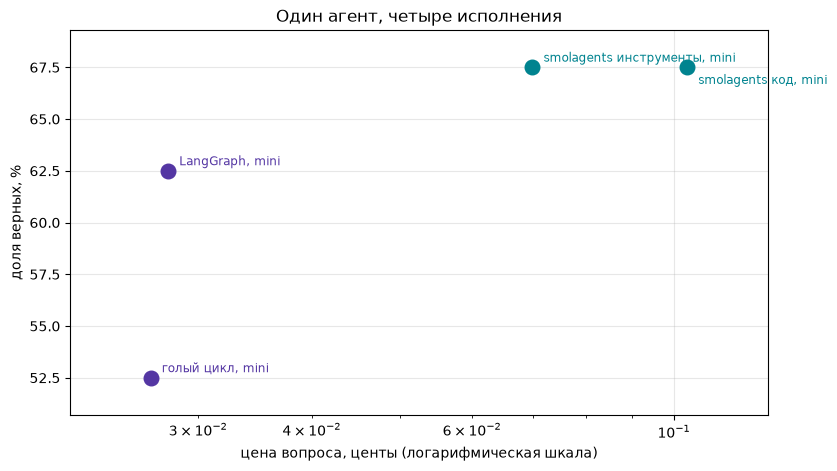

In [37]:
def color_of(tag):
    return COLORS["red"] if "каскад" in tag else COLORS["amber"] if "Sonnet" in tag else COLORS["teal"] if "smolagents" in tag else COLORS["violet"]

def money_chart(tags, path, title):
    table = report(tags)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xscale("log")
    for _, r in table.iterrows():
        ax.scatter(r["центов на вопрос"], r["доля"] * 100, s=110, color=color_of(r["конфигурация"]), zorder=3)
    ax.margins(x=0.15, y=0.12)
    fig.canvas.draw()
    placed = []
    for _, r in table.sort_values("центов на вопрос").iterrows():
        for dx, dy in [(8, 4), (8, -12), (-8, 4), (-8, -12), (8, 16), (8, -24)]:
            label = ax.annotate(r["конфигурация"], (r["центов на вопрос"], r["доля"] * 100), xytext=(dx, dy), textcoords="offset points",
                                fontsize=8.5, ha="left" if dx > 0 else "right", color=color_of(r["конфигурация"]))
            box = label.get_window_extent()
            if not any(box.overlaps(b) for b in placed) or dy == -24:
                break
            label.remove()
        placed.append(box)
    ax.set_xlabel("цена вопроса, центы (логарифмическая шкала)"); ax.set_ylabel("доля верных, %")
    ax.set_title(title); ax.grid(alpha=0.3)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    return table

money_chart(["голый цикл, mini", "LangGraph, mini", "smolagents инструменты, mini", "smolagents код, mini"],
            "img/money_frameworks.png", "Один агент, четыре исполнения")

Кажется что smolagents «лучше всех», но стоит ли этому верить

Наверное Нет.

- Шум. 27/40 против 25/40 это два вопроса при погрешности около ±6. Базовый цикл прыгнул с 26 до 21 между запусками. Различие в 2 вопроса не сильнее этого прыжка.

- Неравные условия. У smolagents 10 шагов вместо 6 и дополнительная подсказка про финал. P.s. Да тут по хорошему надо было ставить меньше шагов ему.
  
- Часть ошибок осталась в других строках. Если п. 1 съел вопросы у цикла и LangGraph, то они искусственно занижены.
  
- Цена верного ответа это главный показатель семинара: 0,1035 цента у smolagents против 0,0445 у LangGraph, то есть в 2,3 раза дороже. Токенов на вопрос 5981 против 1669 (3,6 раза). У smolagents с тулзами большой системный промпт библиотеки и растущий контекст. У CodeAgent ещё хуже: 10019 токенов и 0,1532 цента за верный.

## Спринт 6. Критик графом: LangGraph как явная схема

До сих пор LangGraph был для нас готовым циклом. Его сила в другом: в явном графе, где вы сами решаете, какие узлы есть и куда ведут рёбра. Соберём граф из восьмой лекции: агент отвечает, критик проверяет, при отказе агент получает замечание и ищет заново, но не больше двух попыток.

Критик сделан по уроку восьмой лекции: он не мнение той же модели о своём ответе, а **проверка с опорой**. Узел агента сохраняет в состоянии всё, что вернули инструменты за прогон, а критик сверяет ответ с этими находками. Так ловится главная болезнь агента с поиском: поиск ничего не дал, и модель ответила по памяти. Вердикт приходит не текстом, а объектом Pydantic через `with_structured_output`: так ответ критика не надо разбирать регулярками.

Две дырки. `critic_node`: спросить модель по схеме `Verdict`, показав вопрос, ответ и находки агента, вернуть замечание (пустое, если ответ подтверждён) и увеличенный счётчик проверок. `route`: вернуться к агенту, если есть замечание и попыток было меньше двух, иначе закончить.

Чекпоинт: строка «LangGraph + критик» и счёт «исправил против испортил» относительно LangGraph без критика.

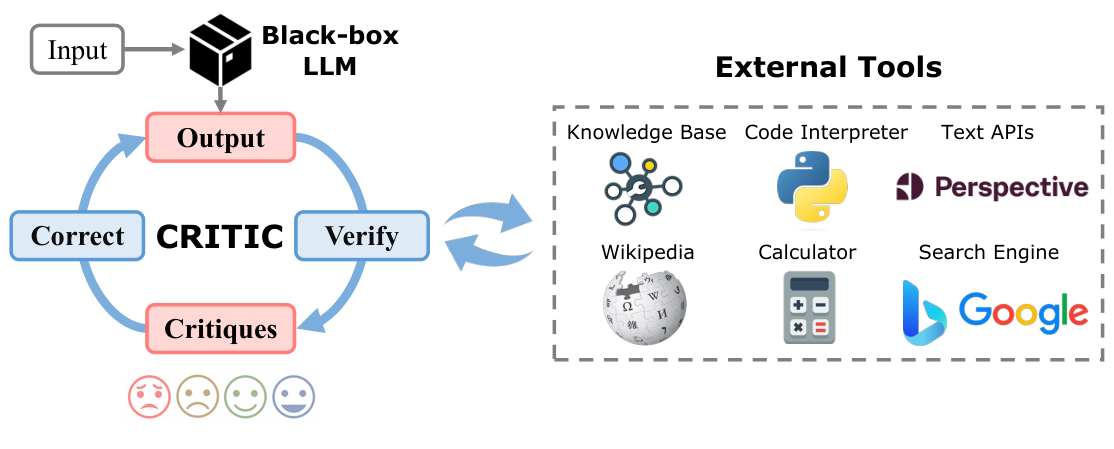

*Gou et al., 2023. CRITIC: проверка ответа с помощью инструментов, а не самооценкой. Так же устроен наш критик*

In [39]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

class QA(TypedDict):
    question: str
    answer: str
    evidence: str
    feedback: str
    rounds: int
    checks: int

class Verdict(BaseModel):
    supported: bool = Field(description="true only if the evidence explicitly supports the answer")
    issue: str = Field(description="what is wrong or missing, empty if supported")

CRITIC_SYSTEM = ("You check a short answer against the evidence the agent retrieved from Wikipedia. Judge only by the evidence. "
                 "If the evidence does not contain the answer, the answer is not supported.")

def answer_node(state):
    note = ""
    if state["feedback"]:
        note = f"\n\nA reviewer rejected your previous answer '{state['answer']}': {state['feedback']} Search again and correct it."
    messages = run_langgraph(state["question"] + note)
    found = "\n".join(str(m.content)[:800] for m in messages if m.type == "tool")
    return {"answer": messages[-1].content, "evidence": found[-4000:], "rounds": state["rounds"] + 1}

In [40]:
def critic_node(state):
    judge = lc_model(CHEAP).with_structured_output(Verdict)
    verdict = judge.invoke([
        ("system", CRITIC_SYSTEM),
        ("user", f"Question: {state['question']}\nAnswer: {state['answer']}\n"
                 f"Evidence the agent found:\n{state['evidence'] or 'nothing'}")
    ])
    return {"feedback": "" if verdict.supported else verdict.issue, "checks": state["checks"] + 1}


In [41]:
def route(state):
    if state["feedback"] and state["rounds"] < 2:
        return 'answer'
    return END


In [42]:
graph = StateGraph(QA)
graph.add_node("answer", answer_node)
graph.add_node("critic", critic_node)
graph.add_edge(START, "answer")
graph.add_edge("answer", "critic")
graph.add_conditional_edges("critic", route, ["answer", END])
checked = graph.compile()
print(checked.get_graph().draw_mermaid())

def ask_checked(question):
    return checked.invoke({"question": question, "answer": "", "evidence": "", "feedback": "", "rounds": 0, "checks": 0})["answer"]

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	answer(answer)
	critic(critic)
	__end__([<p>__end__</p>]):::last
	__start__ --> answer;
	answer --> critic;
	critic -.-> __end__;
	critic -.-> answer;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [43]:
run_config("LangGraph + критик, mini", ask_checked)
base, crit = RESULTS["LangGraph, mini"], RESULTS["LangGraph + критик, mini"]
fixed = sum(not b["ok"] and c["ok"] for b, c in zip(base, crit))
broken = sum(b["ok"] and not c["ok"] for b, c in zip(base, crit))
print("исправил", fixed, "| испортил", broken)
report(["LangGraph, mini", "LangGraph + критик, mini"])

исправил 3 | испортил 0


,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
1,"LangGraph + критик, mini",28/40,0.700,4.5,2472,0.0407,0.0581


Критик помог, и цена вроде не сильно выросла

## Спринт 7. Голосование и каскад по согласию

Восьмая лекция: независимые голоса лечат случайные ошибки, а их согласие это уверенность, которой можно верить. Здесь каждый голос это целый прогон агента с поиском при температуре 0.7, три голоса идут параллельно. Ответы агента пишутся по-разному: «15 March» и «March 15», поэтому сравниваем их как набор слов после нормализации.

Каскад: если все три голоса дешёвой модели совпали, берём ответ. Если нет, задача уходит тому же агенту на Sonnet. Для сравнения тут же строка «LangGraph, Sonnet»: сильная модель на всех вопросах подряд.

Две дырки. `vote`: запустить `k` прогонов параллельно, найти самый частый ответ и вернуть его вместе с долей согласных. `cascade`: три голоса, при полном согласии их ответ, иначе Sonnet.

Чекпоинт: три строки в таблице и число задач, ушедших наверх.

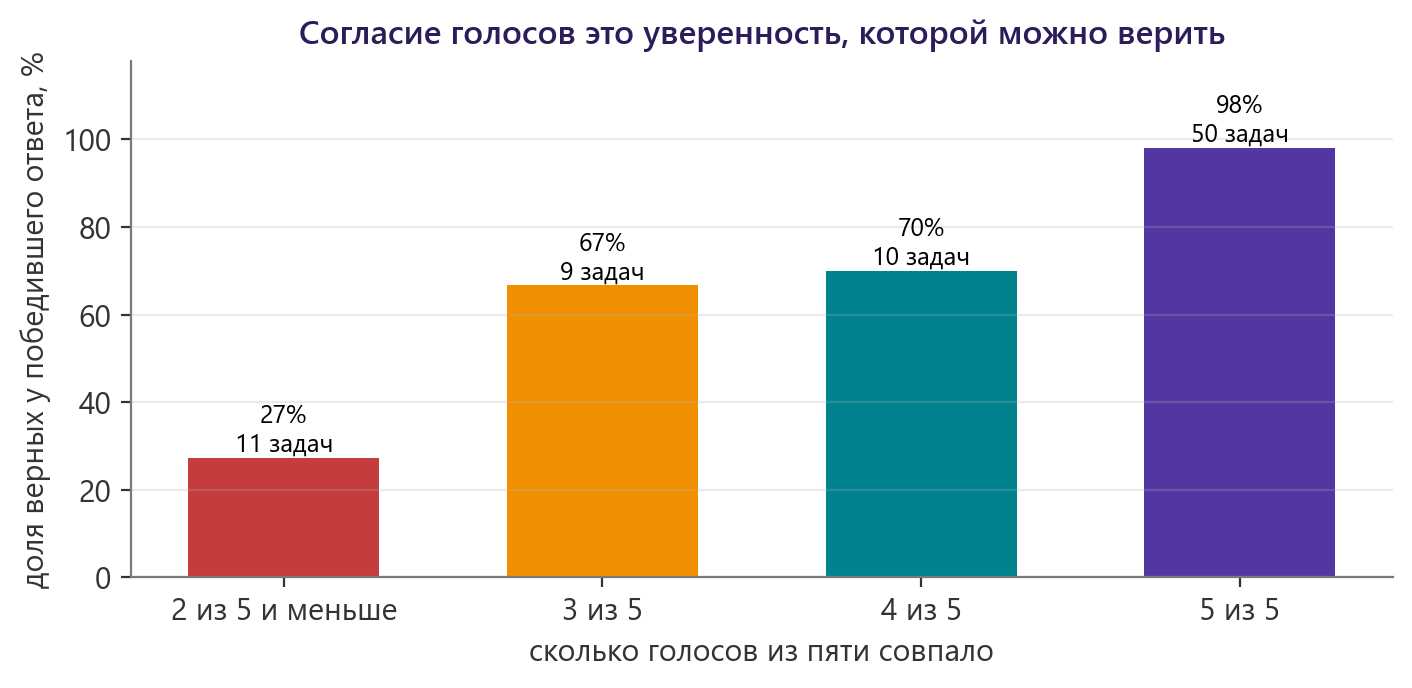

*Из восьмой лекции: когда все пять голосов совпали, ответ верен в 49 случаях из 50. При разногласии верность падает до монетки*

In [44]:
def bag(answer):
    return " ".join(sorted(norm(answer).split()))

In [45]:
from typing import Counter


def vote(question, k=3):
    with ThreadPoolExecutor(k) as ex:
        answers = list(ex.map(lambda _: ask_langgraph(question, CHEAP, 0.7), range(k)))
    keys = [bag(a) for a in answers]
    top, n = Counter(keys).most_common(1)[0]
    return {"answer": answers[keys.index(top)], "agreement": n / k}


In [46]:
def cascade(question):
    v = vote(question, 3)
    if v["agreement"] == 1:
        return v["answer"]
    ESCALATED.append(question)
    return ask_langgraph(question, STRONG)
    


In [47]:
ESCALATED = []
run_config("голосование 3, mini", lambda q: vote(q, 3)["answer"])
run_config("каскад: 3 голоса mini, иначе Sonnet", cascade)
run_config("LangGraph, Sonnet", lambda q: ask_langgraph(q, STRONG), sample=tasks[-STRONG_SAMPLE:])
print("ушло наверх:", len(ESCALATED), "из", len(tasks))
report(["LangGraph, mini", "голосование 3, mini", "каскад: 3 голоса mini, иначе Sonnet", "LangGraph, Sonnet"])

ушло наверх: 26 из 40


,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
1,"голосование 3, mini",22/40,0.550,9.1,5104,0.0854,0.1553
2,"каскад: 3 голоса mini, иначе Sonnet",30/40,0.750,11.4,8595,1.4170,1.8893
3,"LangGraph, Sonnet",30/40,0.750,4.1,6159,2.1908,2.9210


## Спринт 8. Планировщик перед циклом

Девятая лекция: план это текст в контексте исполнителя. Отдельный вызов дешёвой модели пишет короткий план, что искать, и этот план дописывается в системный промпт агента. На наших вопросах мы в девятой лекции видели, что план может и помешать: проверим на своих данных.

У smolagents планирование встроено: параметр `planning_interval` заставляет агента каждые несколько шагов переписывать план. Мы делаем то же руками, чтобы видеть каждый вызов.

Дырка: `plan_then_act`. Попросить дешёвую модель о плане с системным промптом `PLAN_SYSTEM`, затем вызвать `ask_langgraph` с планом в параметре `extra`.

Чекпоинт: строка «план + LangGraph» рядом с LangGraph без плана.

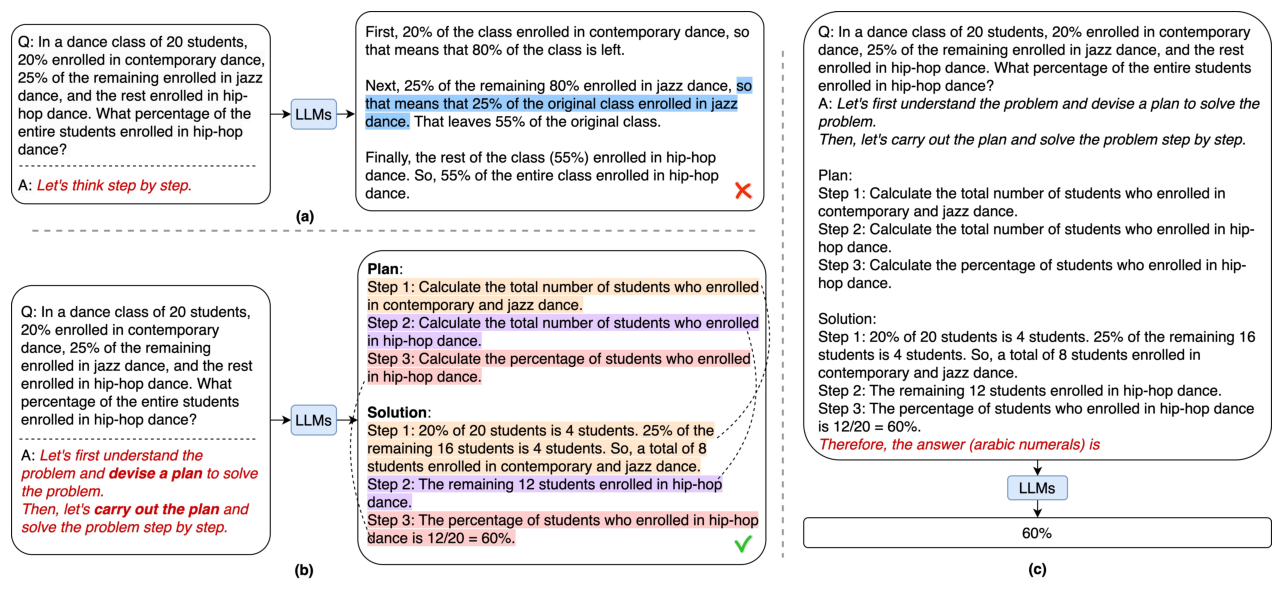

*Wang et al., 2023. Plan-and-Solve: сначала план, потом решение. Самый дешёвый способ планировать, одна фраза и один вызов*

In [50]:
PLAN_SYSTEM = ("Write a short numbered plan (two to four steps) to answer the question with two Wikipedia tools: web_search finds "
               "an article, page_find looks for keywords inside an article. Note that the dataset contain qustion about 2026+ period of time and you can unknown all this fact. Just try to make a plan no find some facts. Plan only, no answer.")

In [51]:
def plan_then_act(question):
    plan = lc_model(CHEAP).invoke([("system", PLAN_SYSTEM), ("user", question)]).content
    return ask_langgraph(question, CHEAP, extra="\nFollow this plan:\n" + plan)


In [52]:
run_config("план + LangGraph, mini", plan_then_act)
report(["LangGraph, mini", "план + LangGraph, mini"])

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
1,"план + LangGraph, mini",26/40,0.650,4.9,2965,0.0515,0.0793


## Спринт 9. Человек в контуре и бюджет

Две вещи, ради которых фреймворк правда стоит своих токенов. Первая: **остановка на подтверждение**. Агенту дают необратимый инструмент, отправку письма. Промежуточный слой `HumanInTheLoopMiddleware` останавливает граф перед вызовом, состояние сохраняется в чекпоинтере, человек решает: одобрить, поправить или отказать с комментарием. Потом граф продолжает с того же места. Руками это десятки строк и своё хранилище состояний.

Вторая: **бюджет**. `ModelCallLimitMiddleware` обрывает прогон после заданного числа вызовов модели. Это не заменяет лимит шагов в цикле, а ставит потолок на деньги сверху, на уровне фреймворка.

Здесь дырок нет, ячейки готовые. Чекпоинт: прерывание с ожидающим вызовом, отказ с комментарием, одобрение и обрыв по бюджету.

In [53]:


@tool
def send_summary(to: str, text: str) -> str:
    """Send a short summary to a colleague by email. Irreversible."""
    return f"sent to {to}: {text}"

TAG["now"] = "человек в контуре"
guarded = create_agent(lc_model(CHEAP), tools=LC_TOOLS + [send_summary], system_prompt=AGENT_SYSTEM.replace(" reply with the short answer only, no explanation", " report what you did"),
                       checkpointer=InMemorySaver(), middleware=[HumanInTheLoopMiddleware(interrupt_on={"send_summary": True})])
thread = {"configurable": {"thread_id": "demo-1"}, "recursion_limit": 14}
out = guarded.invoke({"messages": [{"role": "user", "content": "Find who won the 2026 FIFA World Cup final and email a one-line summary to boss@example.com"}]}, thread)
out["__interrupt__"][0].value["action_requests"]

[{'name': 'send_summary',
  'args': {'to': 'boss@example.com',
   'text': 'Spain won the 2026 FIFA World Cup final against Argentina with a score of 1-0 after extra time.'},
  'description': "Tool execution requires approval\n\nTool: send_summary\nArgs: {'to': 'boss@example.com', 'text': 'Spain won the 2026 FIFA World Cup final against Argentina with a score of 1-0 after extra time.'}"}]

In [54]:
out = guarded.invoke(Command(resume={"decisions": [{"type": "reject", "message": "Добавь в письмо счёт финала"}]}), thread)
out.get("__interrupt__", [None])[0].value["action_requests"] if out.get("__interrupt__") else out["messages"][-1].content

[{'name': 'send_summary',
  'args': {'to': 'boss@example.com',
   'text': 'Spain won the 2026 FIFA World Cup final against Argentina with a score of 1-0 after extra time, with Ferran Torres scoring the winning goal.'},
  'description': "Tool execution requires approval\n\nTool: send_summary\nArgs: {'to': 'boss@example.com', 'text': 'Spain won the 2026 FIFA World Cup final against Argentina with a score of 1-0 after extra time, with Ferran Torres scoring the winning goal.'}"}]

In [55]:
out = guarded.invoke(Command(resume={"decisions": [{"type": "approve"}]}), thread)
print(out["messages"][-1].content)
print("сообщений в сохранённом состоянии:", len(guarded.get_state(thread).values["messages"]))

I found that Spain won the 2026 FIFA World Cup final against Argentina with a score of 1-0 after extra time, with Ferran Torres scoring the winning goal. I then emailed this summary to boss@example.com.
сообщений в сохранённом состоянии: 12


In [56]:
TAG["now"] = "бюджет"
capped = create_agent(lc_model(CHEAP), tools=LC_TOOLS, system_prompt=AGENT_SYSTEM,
                      middleware=[ModelCallLimitMiddleware(run_limit=2, exit_behavior="end")])
out = capped.invoke({"messages": [{"role": "user", "content": "Compare the months of the 2026 Winter Olympics and the 2026 FIFA World Cup, then list three events of each."}]})
print(out["messages"][-1].content[:300])
print("вызовов модели:", sum(c["tag"] == "бюджет" for c in CALLS))

Model call limits exceeded: run limit (2/2)
вызовов модели: 2


## Итог: одна таблица и одна картинка на всю неделю

Все конфигурации семинара на одном поле. Вопрос недели: какой паттерн сдвинул точку вверх или влево, а какой только вправо. И второй: сколько стоит фреймворк сам по себе, без всяких паттернов.

Чекпоинт: `img/money_all.png` и ответ одной фразой, подтвердился ли тезис курса на этой неделе.

,конфигурация,верно,доля,вызовов на вопрос,токенов на вопрос,центов на вопрос,центов за верный
0,"голый цикл, mini",21/40,0.525,2.9,1608,0.0266,0.0507
1,"LangGraph как есть, mini",21/40,0.525,3.0,1599,0.0266,0.0507
2,"LangGraph, mini",25/40,0.625,3.0,1669,0.0278,0.0445
3,"smolagents инструменты, mini",27/40,0.675,3.3,5981,0.0699,0.1035
4,"smolagents код, mini",27/40,0.675,3.4,10019,0.1034,0.1532
5,"LangGraph + критик, mini",28/40,0.700,4.5,2472,0.0407,0.0581
6,"голосование 3, mini",22/40,0.550,9.1,5104,0.0854,0.1553
7,"каскад: 3 голоса mini, иначе Sonnet",30/40,0.750,11.4,8595,1.4170,1.8893
8,"план + LangGraph, mini",26/40,0.650,4.9,2965,0.0515,0.0793
9,"LangGraph, Sonnet",30/40,0.750,4.1,6159,2.1908,2.9210


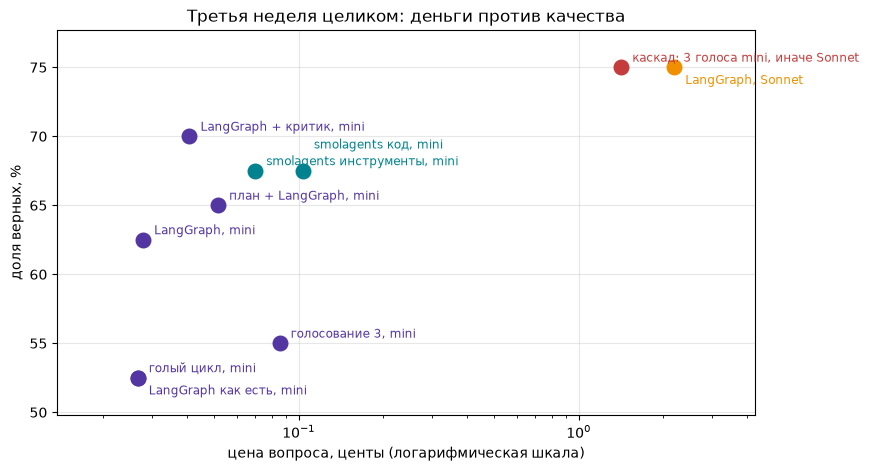

In [57]:
ALL = ["голый цикл, mini", "LangGraph как есть, mini", "LangGraph, mini", "smolagents инструменты, mini", "smolagents код, mini", "LangGraph + критик, mini",
       "голосование 3, mini", "каскад: 3 голоса mini, иначе Sonnet", "план + LangGraph, mini", "LangGraph, Sonnet"]
money_chart(ALL, "img/money_all.png", "Третья неделя целиком: деньги против качества")

In [58]:
spent = pd.DataFrame(CALLS).groupby("tag", sort=False).agg(вызовов=("cost", "size"), центов=("cost", lambda s: round(s.sum() * 100, 3)))
spent, round(pd.DataFrame(CALLS)["cost"].sum(), 3)

(                                        вызовов  центов
 tag                                                    
 проверка счётчика                             1   0.000
 проба                                         6   0.057
 голый цикл, mini                            117   1.064
 LangGraph как есть, mini                    120   1.064
 LangGraph, mini                             119   1.112
 пустой вопрос: голый цикл                     1   0.004
 пустой вопрос: LangGraph                      1   0.004
 пустой вопрос: smolagents, инструменты        1   0.020
 пустой вопрос: smolagents, код                1   0.034
 smolagents инструменты, mini                132   2.795
 smolagents код, mini                        137   4.137
 LangGraph + критик, mini                    178   1.627
 голосование 3, mini                         364   3.417
 каскад: 3 голоса mini, иначе Sonnet         456  56.679
 LangGraph, Sonnet                           164  87.631
 план + LangGraph, mini        

In [71]:
pd.set_option("display.max_colwidth", None)   # не обрезать длинный текст в ячейках
pd.set_option("display.width", 220)           # не переносить колонки на новую строку

pd.DataFrame([{"эталон": t["answer"], "ответ": str(r["answer"])[-180:]}
                         for t, r in zip(tasks, RESULTS["LangGraph + критик, mini"]) if not r["ok"]])

,эталон,ответ
0,GRU Airport People Mover,"The People Mover at São Paulo/Guarulhos International Airport opens on February 20, 2026."
1,Michaelmas Island,"A man was killed in a shark attack off the coast of Western Australia on June 6, 2026."
2,conspiracy to commit arson,"Counter Terrorism Policing investigated a wave of antisemitic attacks targeting the Jewish community in London, including arson and stabbings, linked to Iranian-backed groups."
3,prime minister,"Keir Starmer resigned as the leader of the Labour Party on June 22, 2026."
4,Baku and Tbilisi,hat resumed passenger services in May 2026 include:\n\n1. Beijing and Pyongyang\n2. London and Stirling\n3. Abu Dhabi and Fujairah\n4. Tornio and Haparanda\n5. Bad Bentheim and Coevorden
5,Operation Southern Spear,The operation involved the United States seizing the Russian oil tanker Marinera and the Panama-flagged M Sophia as part of efforts to crack down on Venezuela's energy exports.
6,3 September,ISRO launched EOS-05 on 4 September 2026.
7,Dudzai,Cyclone Narelle.
8,7.1,The earthquake that struck the Kumamoto area of Japan in July 2026 had a magnitude of 6.8.
9,38.1C,"The highest temperature recorded in the UK during the summer of 2026 was 38.0 °C (100.4 °F) in Lingwood, Norfolk on 26 June."


In [77]:
pd.DataFrame([{"эталон": t["answer"], "ответ": str(r["answer"])[-180:]}
                         for t, r in zip(tasks, RESULTS["каскад: 3 голоса mini, иначе Sonnet"]) if not r["ok"]])

,эталон,ответ
0,GRU Airport People Mover,ошибка: RuntimeError
1,Michaelmas Island,ошибка: RuntimeError
2,conspiracy to commit arson,"rs Green stabbings in Barnet, London, which was formally declared a terrorist incident. It was part of a wider wave of antisemitic attacks targeting the Jewish community in London."
3,prime minister,ошибка: RuntimeError
4,SMILE,ошибка: RuntimeError
5,66,"Based on the Wikipedia article on the 2026 Kenya floods, **25 people** were killed nationwide in the floods on March 6–7, 2026 (23 in Nairobi and 2 children in Kitui County)."
6,3 September,EOS-05 (GISAT-1A) was launched on **4 September 2026** at 2:55 am IST from the Satish Dhawan Space Centre aboard the GSLV-F17 mission.
7,Dudzai,Cyclone Narelle
8,Fontainebleau,ошибка: RuntimeError
9,38.1C,ошибка: RuntimeError


In [ ]:
def words(text):
    return set(norm(text).split())

def overlap(ref, ans):
    R, A = words(ref), words(ans)
    return len(R & A) / len(R) if R else 0.0   # защита от пустого эталона

# Фразы отказа: если ответ "верный", но содержит их, это подозрительно
REFUSAL = ("couldn't find", "could not find", "no information", "no specific", "nothing found", "not found")

def suspicion(ok, ref, ans):
    if not ok and overlap(ref, ans) >= 0.5:
        return "ложно-отрицательный?"          # часть эталона есть: возможно, другая формулировка
    if ok and (len(words(ref)) <= 2                      # короткий эталон ловится случайно
               or len(ans) > 150                         # длинный ответ содержит много слов
               or any(p in ans.lower() for p in REFUSAL)):   # отказ, который чем-то совпал
        return "ложно-положительный?"
    return ""

def build_audit(tag):
    rows = []
    for t, r in zip(tasks, RESULTS[tag]):
        a = str(r["answer"])
        rows.append({"id": t["id"], "ok": r["ok"], "вопрос": t["question"], "эталон": t["answer"],
                     "ответ": a, "перекрытие": round(overlap(t["answer"], a), 2),
                     "подозрение": suspicion(r["ok"], t["answer"], a)})
    return pd.DataFrame(rows)

def show(df):
    # Карточки читаются лучше таблицы: вопрос, эталон и ответ целиком
    for _, row in df.iterrows():
        print(f"#{row['id']} ok={row['ok']} перекрытие={row['перекрытие']} {row['подозрение']}\n"
              f"  В: {row['вопрос']}\n  Э: {row['эталон']}\n  О: {row['ответ']}\n")




In [ ]:
audit = build_audit("LangGraph + критик, mini")
show(audit[~audit.ok])                                   # все неверные: ищем ложно-отрицательные


#fresh-106 ok=False перекрытие=0.75 ложно-отрицательный?
  В: What opens at São Paulo/Guarulhos International Airport in February 2026?
  Э: GRU Airport People Mover
  О: The People Mover at São Paulo/Guarulhos International Airport opens on February 20, 2026.

#fresh-108 ok=False перекрытие=0.0 
  В: Where does a man get killed in a shark attack in June 2026?
  Э: Michaelmas Island
  О: A man was killed in a shark attack off the coast of Western Australia on June 6, 2026.

#fresh-109 ok=False перекрытие=0.5 ложно-отрицательный?
  В: What type of incident is investigated by Counter Terrorism Policing in May 2026?
  Э: conspiracy to commit arson
  О: Counter Terrorism Policing investigated a wave of antisemitic attacks targeting the Jewish community in London, including arson and stabbings, linked to Iranian-backed groups.

#fresh-111 ok=False перекрытие=0.0 
  В: What position did Keir Starmer resign from on June 22, 2026 in the United Kingdom?
  Э: prime minister
  О: Keir Starmer res

Ответил #fresh-106; #fresh-109; #fresh-144
Не точно #fresh-108;
Неоднозначность #fresh-111;
Не правильно #fresh-119; #fresh-120; #fresh-133; #fresh-141
Инфа поменялась #fresh-130; #fresh-135 (отличаются версии Японии и США); #fresh-138

In [ ]:
audit = build_audit("LangGraph + критик, mini")
show(audit[~audit.ok])                                   # все неверные: ищем ложно-отрицательные


## Дополнение: дерево мыслей против инструмента

Для тех, кто закончил раньше. Девятая лекция: на «Игре в 24» дерево мыслей подняло mini с 10 до 83 процентов за 0,61 цента на задачу, а инструмент с кодом решил всё за 0,024 цента. Повторим короткую версию на десяти задачах: цепочка рассуждений против кода, который модель пишет сама. Дерево здесь не строим, его цифры есть в лекции.

In [144]:
import ast, subprocess, sys, csv, io
from fractions import Fraction

def value(node):
    if isinstance(node, ast.Constant):
        return Fraction(str(node.value))
    if isinstance(node, ast.BinOp):
        a, b = value(node.left), value(node.right)
        return {ast.Add: a + b, ast.Sub: a - b, ast.Mult: a * b, ast.Div: a / b if b else Fraction(10**9)}[type(node.op)]
    raise ValueError

def solved(expr, puzzle):
    expr = (expr or "").replace("×", "*").replace("÷", "/").split("=")[0].strip().strip("`$ ")
    try:
        return sorted(re.findall(r"\d+", expr)) == sorted(puzzle.split()) and value(ast.parse(expr, mode="eval").body) == 24
    except Exception:
        return False

raw = httpx.get("https://raw.githubusercontent.com/princeton-nlp/tree-of-thought-llm/master/src/tot/data/24/24.csv", timeout=60).text
puzzles = [r["Puzzles"] for r in csv.DictReader(io.StringIO(raw))][900:910]

def cot(p):
    text = chat([{"role": "system", "content": "Use each number once with + - * / and parentheses to get 24. Think step by step. Last line: FINAL: <expression>"},
                 {"role": "user", "content": p}])["content"] or ""
    found = re.findall(r"FINAL:\s*(.+)", text)
    return found[-1] if found else ""

def by_code(p):
    code_text = chat([{"role": "system", "content": "Write a Python program that finds by brute force an expression using each of the four numbers once with + - * / and parentheses that equals 24. Print only the expression. Reply with code only."},
                      {"role": "user", "content": p}])["content"] or ""
    code_text = re.sub(r"^```(?:python)?|```$", "", code_text.strip(), flags=re.M)
    try:
        out = subprocess.run([sys.executable, "-c", code_text], capture_output=True, text=True, timeout=15).stdout.strip().splitlines()
        return out[-1] if out else ""
    except subprocess.TimeoutExpired:
        return ""

rows = []
for name, fn in [("цепочка рассуждений, mini", cot), ("код, mini", by_code)]:
    TAG["now"] = f"игра в 24: {name}"
    got = pmap(fn, puzzles)
    cost = sum(c["cost"] for c in CALLS if c["tag"] == TAG["now"])
    rows.append({"способ": name, "решено": sum(solved(g, p) for g, p in zip(got, puzzles)), "центов на задачу": round(cost / len(puzzles) * 100, 4)})
pd.DataFrame(rows)

,способ,решено,центов на задачу
0,"цепочка рассуждений, mini",1,0.2147
1,"код, mini",10,0.0225
